In [2]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 30.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

# (lab7) CSP

##  The Problem Definition:
- *Variables*: $x, y, z$
- *Domains*: Each variable must be an integer between 1 and 5.
- *Constraints*:
  - $x \neq y$ (x and y must be different)
  - $y > z$ (y must be strictly greater than z)
  - $x + z = y$ (the sum of x and z must equal y)

In [3]:
from ortools.sat.python import cp_model

def solve_general_csp():
    # 1. Initialize the model
    model = cp_model.CpModel()

    # 2. Define Variables & Domains (1 through 5)
    x = model.new_int_var(1, 5, "x")
    y = model.new_int_var(1, 5, "y")
    z = model.new_int_var(1, 5, "z")

    # 3. Add Constraints
    model.add(x != y)
    model.add(y > z)
    model.add(x + z == y)

    # 4. Create the solver
    solver = cp_model.CpSolver()
    status = solver.solve(model)

    # 5. Extract and print the results
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print("General CSP Solution Found:")
        print(f"x = {solver.value(x)}")
        print(f"y = {solver.value(y)}")
        print(f"z = {solver.value(z)}")
    else:
        print("No solution found.")

solve_general_csp()

General CSP Solution Found:
x = 1
y = 5
z = 4


## N-Queens
- Variables: $Q_0, Q_1, Q_2, \dots, Q_{N-1}$ (where $Q_i$ represents the row position of the queen in column $i$)
- Domains: Each $Q_i$ must be an integer between $0$ and $N-1$.
- Constraints:
  - *Row Constraint*: No two queens can share the same row.$$Q_i \neq Q_j \quad \forall i \neq j$$
  - *Positive Diagonal Constraint*: No two queens can share a diagonal sloping upwards. For any square on this diagonal, the sum of its row and column coordinates is a constant.$$Q_i + i \neq Q_j + j \quad \forall i \neq j$$
  - *Negative Diagonal Constraint*: No two queens can share a diagonal sloping downwards. For any square on this diagonal, the difference between its row and column coordinates is a constant.$$Q_i - i \neq Q_j - j \quad \forall i \neq j$$

In [4]:
from ortools.sat.python import cp_model

def solve_n_queens(board_size=8):
    # 1. Initialize the model
    model = cp_model.CpModel()

    # 2. Define Variables & Domains
    # queens[i] is the row index for the queen in column i
    queens = [model.new_int_var(0, board_size - 1, f"Q_{i}") for i in range(board_size)]

    # 3. Add Constraints
    # Constraint 1: All rows must be different
    model.add_all_different(queens)

    # Constraint 2: All positive diagonals (row + col) must be different
    model.add_all_different([queens[i] + i for i in range(board_size)])

    # Constraint 3: All negative diagonals (row - col) must be different
    model.add_all_different([queens[i] - i for i in range(board_size)])

    # 4. Create the solver
    solver = cp_model.CpSolver()
    status = solver.solve(model)

    # 5. Extract and print the results (printing just one valid solution)
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"\nSolution for {board_size}-Queens:")
        for i in range(board_size):
            row_str = ""
            for j in range(board_size):
                # If the value of the queen in column j equals the current row i
                if solver.value(queens[j]) == i:
                    row_str += "Q "
                else:
                    row_str += ". "
            print(row_str)
    else:
        print("No solution found.")

solve_n_queens(8)


Solution for 8-Queens:
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 
. Q . . . . . . 


 # (lab8) Adversarial Search Evolutionary Search Algorithms

In [ ]:
# @title
import networkx as nx
import matplotlib.pyplot as plt

def draw_tree(root_node):
    G = nx.DiGraph()
    labels = {}
    pos = {}

    # Helper to build the graph
    def build_graph(node, x=0, y=0, layer=1):
        label = f"{node.name}\n(V:{node.value})" if node.is_terminal() else node.name
        labels[node.name] = label
        pos[node.name] = (x, y)

        for i, child in enumerate(node.children):
            G.add_edge(node.name, child.name)
            # Spread children out horizontally based on layer depth
            width = 2 / (layer)
            new_x = x - width/2 + i * width
            build_graph(child, x=new_x, y=y-1, layer=layer+1)

    build_graph(root_node)

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, labels=labels,
            node_size=3000, node_color="lightblue",
            font_size=10, font_weight="bold", arrows=True)
    plt.title("Minimax Game Tree")
    plt.show()

## MinMax

In [ ]:
class Node:
    # We need 'name' here so the computer knows what "L1" is!
    def __init__(self, name, value=None, children=None):
        self.name = name
        self.value = value
        self.children = children or []

    def is_terminal(self):
        return len(self.children) == 0

    def evaluate(self):
        return self.value

    def get_children(self):
        return self.children

In [ ]:
def minmax(node,depth,maximizingPlayer):
    if depth == 0 or node.is_terminal():
        return node.evaluate()

    if maximizingPlayer:
        max_eva = float('-inf')
        for child in node.get_children():
            eva = minmax(child,depth-1,False)
            max_eva = max(max_eva,eva)
        return max_eva
    else:
        min_eva = float('inf')
        for child in node.get_children():
            eva = minmax(child,depth-1,True)
            min_eva = min(min_eva,eva)
        return min_eva

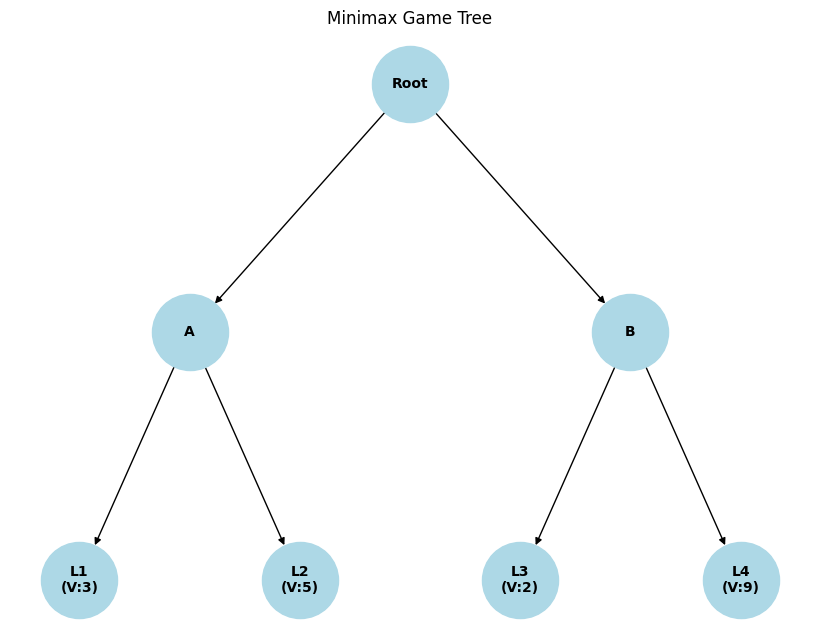

The optimal score for the Maximizer is: 3


In [ ]:
# Level 2: Leaf Nodes (The outcomes)
leaf1 = Node("L1", value=3)
leaf2 = Node("L2", value=5)
leaf3 = Node("L3", value=2)
leaf4 = Node("L4", value=9)

# Level 1: Decision Nodes (The opponent's turn)
node_A = Node("A", children=[leaf1, leaf2])
node_B = Node("B", children=[leaf3, leaf4])

# Level 0: Root Node (Your turn)
root = Node("Root", children=[node_A, node_B])

# Run the visualization
draw_tree(root)

result = minmax(root, depth=2, maximizingPlayer=True)
print(f"The optimal score for the Maximizer is: {result}")

In [ ]:
def minimax_ab(node, depth, alpha, beta, maximizingPlayer):
    if depth == 0 or node.is_terminal():
        return node.evaluate()

    if maximizingPlayer:
        max_eva = float('-inf')
        for child in node.get_children():
            eva = minimax_ab(child, depth - 1, alpha, beta, False)
            max_eva = max(max_eva, eva)
            alpha = max(alpha, eva)
            if beta <= alpha:
                break
        return max_eva

    else:
        min_eva = float('inf')
        for child in node.get_children():
            eva = minimax_ab(child, depth - 1, alpha, beta, True)
            min_eva = min(min_eva, eva)
            beta = min(beta, eva)
            if beta <= alpha:
                break
        return min_eva

In [ ]:
result = minimax_ab(root, 2, float('-inf'), float('inf'), True)
print(f"The optimal score for the Maximizer is: {result}")

The optimal score for the Maximizer is: 3


# (Lab12) EDA

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Phase 1: Loading & Initial Inspection
# ==========================================
print("--- 1. LOADING DATA ---")
# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

print("\nFirst 3 rows:")
print(df.head(3))

print("\nDataset Info (Checking for missing values & types):")
print(df.info())

--- 1. LOADING DATA ---

First 3 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  

Dataset Info (Checking for missing values & types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 no

In [26]:

# ==========================================
# Phase 2: Data Cleaning & Transformation
# ==========================================
print("\n--- 2. DATA CLEANING ---")
# The 'deck' column has too many missing values (mostly null), so we drop it
df.drop('deck', axis=1, inplace=True)

# The 'age' column has some missing values. We fill them with the median age.
df['age'] = df['age'].fillna(df['age'].median())

print("Missing values after cleaning:\n", df.isnull().sum()[['age', 'embarked']])


--- 2. DATA CLEANING ---
Missing values after cleaning:
 age         0
embarked    2
dtype: int64


In [27]:

# ==========================================
# Phase 3: Aggregation & Grouping
# ==========================================
print("\n--- 3. AGGREGATION & CROSSTABS ---")

# Let's look at survival rates based on ticket class using groupby
class_survival = df.groupby('class')['survived'].mean() * 100
print("\nSurvival Rate by Class (%):")
print(class_survival)

# Let's use a crosstab to see Gender vs. Survival
gender_crosstab = pd.crosstab(df['sex'], df['survived'], normalize='index') * 100
print("\nSurvival Rate by Gender (%):")
print(gender_crosstab)




--- 3. AGGREGATION & CROSSTABS ---

Survival Rate by Class (%):
class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

Survival Rate by Gender (%):
survived          0          1
sex                           
female    25.796178  74.203822
male      81.109185  18.890815



--- 4. VISUAL ANALYSES ---


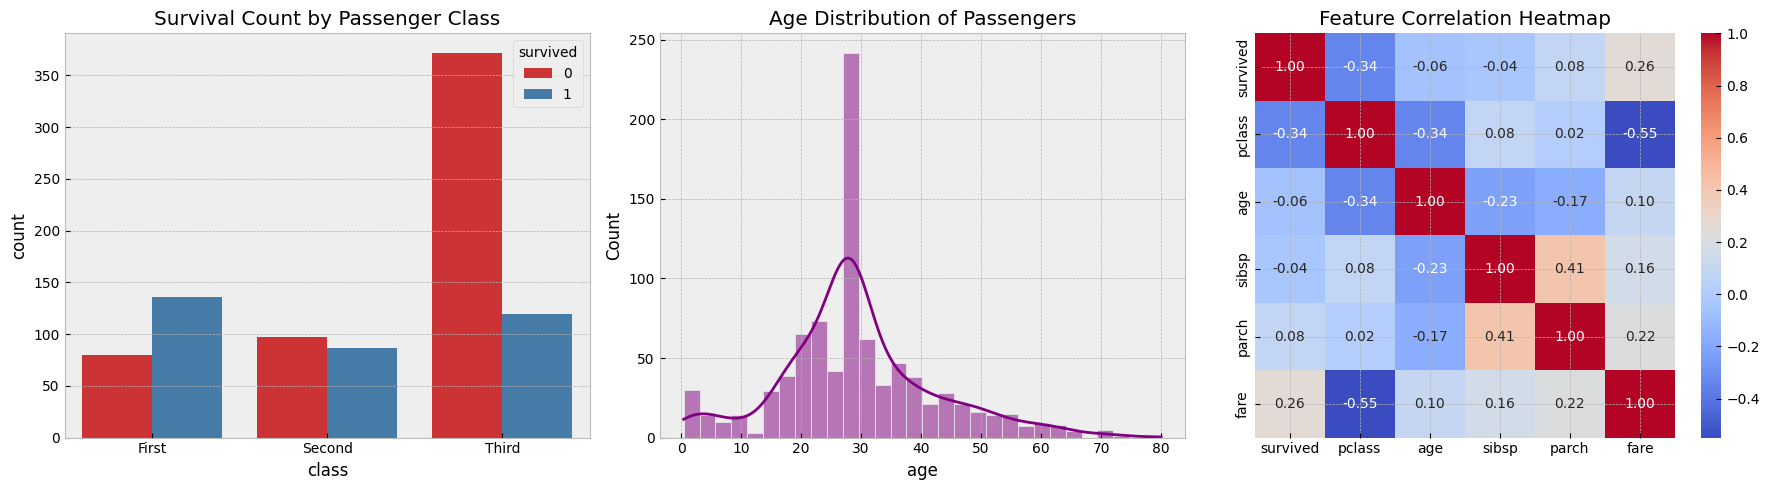

In [28]:
# ==========================================
# Phase 4: Visualizations
# ==========================================
print("\n--- 4. VISUAL ANALYSES ---")
# Set a nice style for our plots
plt.style.use('bmh')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Countplot of Survival by Class
sns.countplot(x='class', hue='survived', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('Survival Count by Passenger Class')

# Plot 2: Distribution of Ages
sns.histplot(df['age'], bins=30, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Age Distribution of Passengers')

# Plot 3: Correlation Heatmap (Numerical features only)
# We select only numerical columns for correlation
df_num = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

# (Lab10) supervised learning

## Support Vector Machine

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = datasets.load_iris()
# IMPORTANT: Use only the first two features for 2D visualization
X = iris.data[:, :2]
y = iris.target
y = (y == 0).astype(int) # Convert to binary classification problem

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM model with RBF kernel
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)

# Make predictions
y_pred = svm.predict(X_test)

# Evaluate the model
acc = accuracy_score(y_test, y_pred)
print('SVM Accuracy:', acc)

SVM Accuracy: 1.0


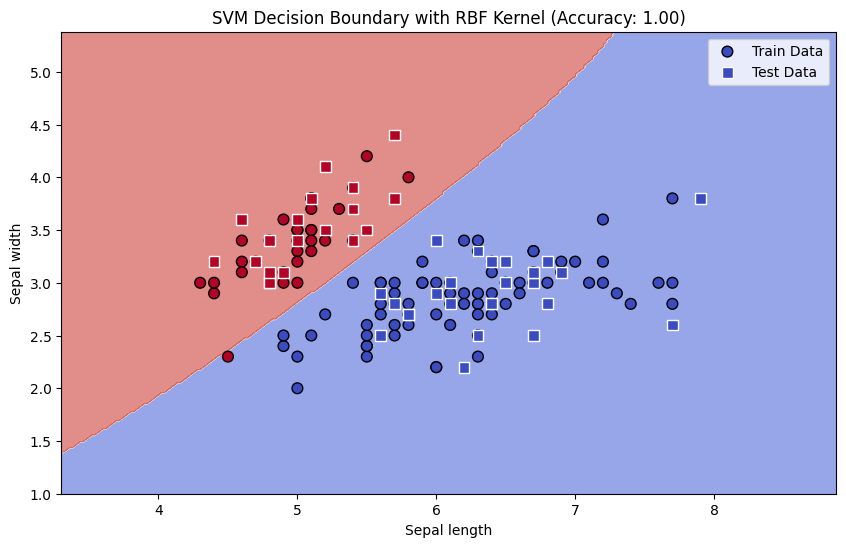

In [16]:
# @title
# ==========================================
# Plotting the Decision Boundary (OPTIONAL)
# ==========================================

# 1. Create a mesh grid (a grid of dense points across the plot area)
h = 0.02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 2. Predict the classification for each point in the meshgrid
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))

# 3. Draw the background filled contour to show the decision regions
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)

# 4. Plot the original training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm,
            edgecolors='k', marker='o', s=60, label='Train Data')

# 5. Plot the testing points (with white edges and square markers to stand out)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm,
            edgecolors='w', marker='s', s=60, label='Test Data')

# 6. Add labels and aesthetics
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f'SVM Decision Boundary with RBF Kernel (Accuracy: {acc:.2f})')
plt.legend()

# Display the plot
plt.savefig('svm_decision_boundary.png', bbox_inches='tight')

## Linear Regression

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load dataset
iris = datasets.load_iris()
X = iris.data
# df = pd.DataFrame()
# df = X
# print(df)
y = iris.target
y = (y == 0).astype(int) # Convert to binary classification problem

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create and train the Linear Regression model
LR = LinearRegression()
ModelLR = LR.fit(x_train, y_train)
# Predict on the test data
PredictionLR = ModelLR.predict(x_test)
# Print the predictions
print('Predictions:', PredictionLR)

Predictions: [ 0.06858754  1.00867146 -0.44710026  0.11520442  0.06738308  0.9268164
  0.30149058  0.03285725 -0.05930489  0.19989713  0.05860855  0.83360058
  1.01238455  0.84301552  1.02396928  0.1851498  -0.15568455  0.14419308
  0.08710758 -0.16992588  0.83271001  0.04251129  0.88704775 -0.16397104
  0.00190482 -0.02397524 -0.25389267 -0.11680648  0.82169091  0.81105763]


In [8]:
from sklearn.metrics import r2_score
print('===================LR Testing Accuracy================')
teachLR = r2_score(y_test, PredictionLR)
testingAccLR = teachLR * 100
print(testingAccLR)

===================LR Testing Accuracy================
88.73227699320645


## D-Trees

In [10]:
from sklearn.tree import DecisionTreeClassifier
# Initialize the DecisionTreeClassifier
DT = DecisionTreeClassifier()
# Train the model
ModelDT = DT.fit(x_train, y_train)
# Model Testing (Prediction)
PredictionDT = DT.predict(x_test)
print('Predictions:', PredictionDT)

# Model Training Accuracy
print('====================DT Training Accuracy===============')
tracDT = DT.score(x_train, y_train) # The score method gives accuracy directly
print(f'Training Accuracy: {tracDT:.2f}')
# Model Testing Accuracy
print('=====================DT Testing Accuracy=================')
teacDT = accuracy_score(y_test, PredictionDT)
print(f'Testing Accuracy: {teacDT:.2f}')

Predictions: [0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1]
====================DT Training Accuracy===============
Training Accuracy: 1.00
=====================DT Testing Accuracy=================
Testing Accuracy: 1.00


# (Lab11) Unsupervised Learning

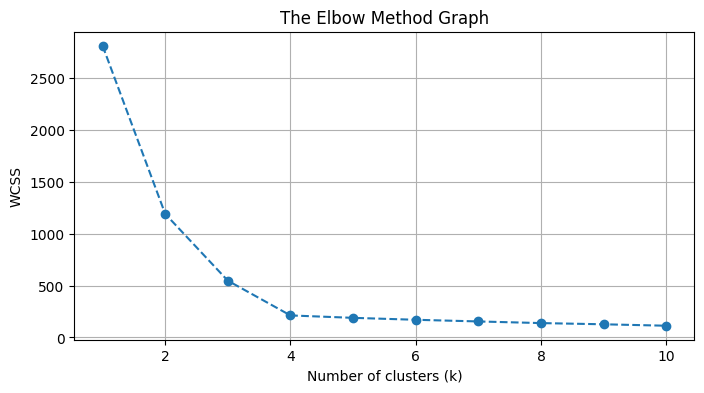

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate Synthetic Data (Simulating our 'Customers')
# We create 300 points naturally grouping into 4 clusters
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# ==========================================
# Phase 1: The Elbow Method
# ==========================================
wcss_list = [] # Within-Cluster Sum of Square

# Test 1 to 10 clusters to find the "elbow"
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X)
    wcss_list.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss_list, marker='o', linestyle='--')
plt.title('The Elbow Method Graph')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


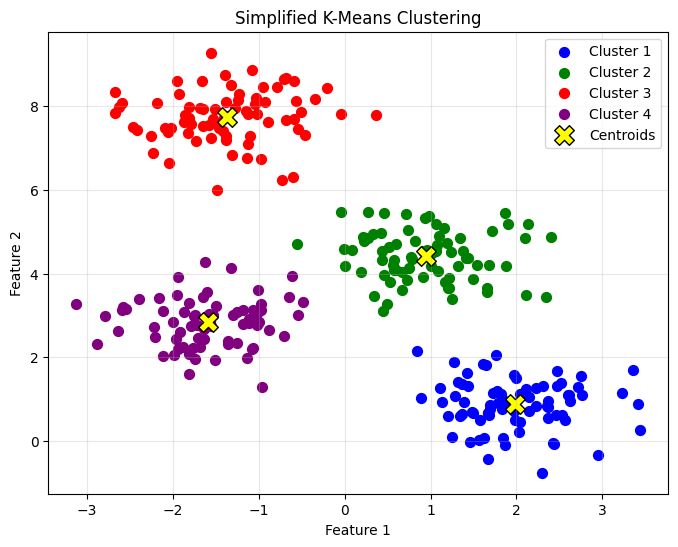

In [22]:

# ==========================================
# Phase 2: Training and Visualizing K-Means
# ==========================================
# Based on our generated data, we know the optimal 'k' is 4.
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
y_predict = kmeans.fit_predict(X)

# Plot the Clusters
plt.figure(figsize=(8, 6))

# A simpler, dynamic way to plot all clusters using a loop
colors = ['blue', 'green', 'red', 'purple']
for i in range(4):
    plt.scatter(X[y_predict == i, 0], X[y_predict == i, 1],
                s=50, c=colors[i], label=f'Cluster {i+1}')

# Plot the Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', edgecolors='black', marker='X', label='Centroids')

plt.title('Simplified K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()